# Задача 1: Лингвистика и синтаксический разбор текстовых данных

## Описание задачи
Выполнение лингвистического анализа текстовых данных с использованием библиотек для синтаксического разбора (`spacy`) и морфологического анализа.

## Цель задачи
- Найти в текстах подлежащие и сказуемые
- Построить зависимость их совместных употреблений
- Визуализировать результаты

## Импорт необходимых библиотек

In [2]:
# Стандартные библиотеки
from collections import Counter
import sqlite3
import re

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import seaborn as sns

# Лингвистические библиотеки
import spacy

# Настройка отображения графиков
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## Загрузка данных из БД

In [3]:
def load_texts(file_path):
    """
    Загружает текстовые данные из SQLite базы данных.
    
    Args:
        file_path: путь к БД с новостными статьями
    
    Returns:
        df: DataFrame с одним столбцом текстов статей
    """
    with sqlite3.connect(file_path) as conn:
        query = """
        SELECT description as text FROM articles WHERE description IS NOT NULL
        """
        df = pd.read_sql(query, conn)
    
    print(f"Загружено записей: {len(df)}")
    return df

In [4]:
# Загрузка данных
dff = load_texts('lenta.db')
df = dff[49999:]
df.head(10)

Загружено записей: 99999


,text
49999,В Краснодаре милиционер застрелил автомобилист...
50000,Рабочая группа по вопросам развития безналичны...
50001,Бортпроводники компании British Airways объяви...
50002,Общественный патрульныйДжордж Циммерманполучил...
50003,Вооруженные бандиты в масках ограбили ювелирны...
50004,Торговая марка кормов для животных Friskies вы...
50005,КПРФотказалась от обжалования итогов президент...
50006,"Глава Нацбанка Казахстана Григорий Марченко, в..."
50007,"Участники Muse заявили, что группа выпустит но..."
50008,Депутат от КПРФ Владимир Федоткин предложил пр...


## Очистка и предобработка текста

In [5]:
def clean_text(text):
    """
    Полная очистка текста с обработкой спецсимволов и знаков препинания.
    
    Args:
        text: исходный текст
    
    Returns:
        cleaned_text: очищенный текст
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Замена спецсимволов переноса на пробелы
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    
    # 2. Разделение стыков Латиница/Кириллица
    text = re.sub(r'([a-zA-Z])([а-яА-Я])', r'\1 \2', text)
    text = re.sub(r'([а-яА-Я])([a-zA-Z])', r'\1 \2', text)
    
    # 3. Обработка знаков препинания
    punctuation = ',.:;!?'
    
    # 3а. Убираем пробелы ПЕРЕД знаками препинания
    pattern_before = r'\s+([' + re.escape(punctuation) + r'])'
    text = re.sub(pattern_before, r'\1', text)
    
    # 3б. Добавляем пробел ПОСЛЕ знаков препинания
    pattern_after = r'([' + re.escape(punctuation) + r'])([А-Яа-яA-Za-z])'
    text = re.sub(pattern_after, r'\1 \2', text)
    
    # 4. Обработка скобок
    text = re.sub(r'\(\s+', r'(', text)
    text = re.sub(r'([А-Яа-яA-Za-z0-9])\(', r'\1 (', text)
    text = re.sub(r'\s+\)', r')', text)
    text = re.sub(r'\)([А-Яа-яA-Za-z0-9])', r') \1', text)
    
    # 5. Все множественные пробелы превращаем в один
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [6]:
# Очистка данных
tqdm.pandas()
print('Очистка текстовых данных...')
df['clean_text'] = df['text'].progress_apply(clean_text)
print(f"Обработано записей: {len(df)}")
df['clean_text'].head()

Очистка текстовых данных...


100%|██████████| 50000/50000 [00:07<00:00, 6941.33it/s]

Обработано записей: 50000


49999    В Краснодаре милиционер застрелил автомобилист...
50000    Рабочая группа по вопросам развития безналичны...
50001    Бортпроводники компании British Airways объяви...
50002    Общественный патрульныйДжордж Циммерманполучил...
50003    Вооруженные бандиты в масках ограбили ювелирны...
Name: clean_text, dtype: str

## Инициализация инструментов синтаксического разбора

In [8]:
# Инициализация spacy с русской моделью
print('Загрузка модели spaCy...')
nlp = spacy.load("ru_core_news_md")
print("Модель успешно загружена!")

Загрузка модели spaCy...
Модель успешно загружена!


## Функция извлечения пар подлежащее-сказуемое

In [9]:
def extract_subject_predicate_pairs(doc):
    """
    Извлекает все пары (подлежащее, сказуемое) из документа.
    
    Args:
        doc: объект Document из spaCy
    
    Returns:
        found_pairs: список кортежей (подлежащее, сказуемое)
    """
    found_pairs = []
    
    for sent in doc.sents:
        predicates = []
        
        # Поиск сказуемых (глаголы и вспомогательные глаголы)
        for token in sent:
            if token.pos_ in ['VERB', 'AUX']:
                # Сказуемое - это ROOT или союзное соединение
                if token.dep_ in ["ROOT", "conj"]:
                    predicates.append(token)
        
        # Для каждого сказуемого ищем подлежащее
        for pred in predicates:
            subject = None
            
            # Ищем среди детей сказуемого
            for child in pred.children:
                if child.dep_ in ["nsubj", "nsubj:pass"]:
                    subject = child
                    break
            
            # Если пара найдена, сохраняем леммы в нижнем регистре
            if subject and subject.pos_ in ["NOUN", "PROPN", "PRON"]:
                found_pairs.append((subject.lemma_.lower(), pred.lemma_.lower()))
    
    return found_pairs

## Многопоточная обработка текстов

In [10]:
def process_texts_multithread(df, n_process=9, batch_size=50):
    """
    Многопоточная обработка текстов для извлечения пар подлежащее-сказуемое.
    
    Args:
        df: DataFrame с текстами
        n_process: количество процессов для параллельной обработки
        batch_size: размер батча для обработки
    
    Returns:
        results: список списков пар для каждого документа
    """
    texts = df['clean_text'].fillna('').tolist()
    results = []
    
    # Основная функция многопоточности spaCy
    docs_stream = nlp.pipe(texts, batch_size=batch_size, n_process=n_process)
    
    for doc in tqdm(docs_stream, total=len(texts), desc="Обработка текстов"):
        pairs = extract_subject_predicate_pairs(doc)
        results.append(pairs)
    
    return results

In [11]:
# Обработка всех текстов
print("Начало обработки текстов...")
df['pairs'] = process_texts_multithread(df)
print("Обработка завершена!")
df['pairs'].head()

Начало обработки текстов...


Обработка текстов: 100%|██████████| 50000/50000 [06:04<00:00, 137.18it/s]

Обработка завершена!


49999    [(милиционер, застрелить), (агентство"интерфак...
50000    [(группа, подготовить), (газета"ведомости, пис...
50001    [(бортпроводник, объявить), (то, стать), (заба...
50002    [(результат, оказаться), (врач, засвидетельств...
50003    [(бандит, ограбить), (преступник, совершить), ...
Name: pairs, dtype: object

## Построение зависимостей совместных употреблений

In [12]:
# Сбор всех пар в один список
all_pairs = []
for pair_list in df['pairs']:
    all_pairs.extend(pair_list)

# Подсчёт частот с помощью Counter
counter = Counter(all_pairs)

# Вывод ТОП-20 самых частых пар
top_20 = counter.most_common(20)

print("=" * 70)
print("ТОП-20 самых частых пар (Подлежащее — Сказуемое):")
print("=" * 70)
print(f"{'#':<3} | {'Подлежащее':<20} | {'Сказуемое':<20} | {'Частота'}")
print("-" * 70)

for i, ((subj, verb), count) in enumerate(top_20, 1):
    print(f"{i:<3} | {subj:<20} | {verb:<20} | {count}")

print("=" * 70)
print(f"Всего уникальных пар: {len(counter)}")
print(f"Всего пар найдено: {len(all_pairs)}")

ТОП-20 самых частых пар (Подлежащее — Сказуемое):
#   | Подлежащее           | Сказуемое            | Частота
----------------------------------------------------------------------
1   | дело                 | возбудить            | 1874
2   | человек              | погибнуть            | 1626
3   | речь                 | идти                 | 1454
4   | инцидент             | произойти            | 1410
5   | решение              | принять              | 1076
6   | обвинение            | предъявить           | 836
7   | представитель        | заявить              | 811
8   | сайт                 | сообщать             | 797
9   | газета               | писать               | 631
10  | суд                  | признать             | 573
11  | он                   | отметить             | 572
12  | он                   | заявить              | 565
13  | взрыв                | произойти            | 549
14  | это                  | произойти            | 518
15  | агентство            | с

## Визуализация результатов

In [13]:
def visualize_results(counter, top_n=20):
    """
    Визуализация результатов анализа.
    
    Args:
        counter: Counter с парами (подлежащее, сказуемое)
        top_n: количество топовых сочетаний для отображения
    """
    # Получаем топ-N пар
    top = counter.most_common(top_n)
    
    # Создаем DataFrame для визуализации
    df_viz = pd.DataFrame(top, columns=['Pair', 'Count'])
    df_viz['Subject'] = df_viz['Pair'].apply(lambda x: x[0])
    df_viz['Verb'] = df_viz['Pair'].apply(lambda x: x[1])
    df_viz['Label'] = df_viz['Subject'] + ' — ' + df_viz['Verb']
    
    # Настройка стиля
    sns.set_theme(style="whitegrid", context="notebook")
    
    # График 1: Столбчатая диаграмма ТОП-N пар
    plt.figure(figsize=(14, 10))
    sns.barplot(data=df_viz, x='Count', y='Label', palette='YlOrRd', hue='Label', legend=False)
    plt.title(f'Топ-{top_n} наиболее частых пар (Подлежащее — Сказуемое)', fontsize=16, weight='bold', pad=20)
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Грамматическая пара', fontsize=12)
    plt.tight_layout()
    plt.savefig('top_pairs_barplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # График 2: Тепловая карта матрицы совместимости
    top_subjects = [p[0][0] for p in counter.most_common(100)]
    top_verbs = [p[0][1] for p in counter.most_common(100)]
    
    unique_subjects = list(dict.fromkeys(top_subjects))[:15]
    unique_verbs = list(dict.fromkeys(top_verbs))[:15]
    
    matrix_data = []
    for subj in unique_subjects:
        row = []
        for verb in unique_verbs:
            count = counter.get((subj, verb), 0)
            row.append(count)
        matrix_data.append(row)
    
    df_matrix = pd.DataFrame(matrix_data, index=unique_subjects, columns=unique_verbs)
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(df_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                linewidths=.5, cbar_kws={'label': 'Частота'},
                annot_kws={'size': 8})
    plt.title('Матрица совместимости: Топ-15 Подлежащих vs Топ-15 Сказуемых', 
              fontsize=14, weight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('compatibility_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # График 3: Распределение частот (гистограмма)
    plt.figure(figsize=(12, 6))
    frequencies = [count for _, count in counter.most_common(500)]
    plt.hist(frequencies, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title('Распределение частот пар (Подлежащее — Сказуемое)', fontsize=14, weight='bold')
    plt.xlabel('Частота', fontsize=12)
    plt.ylabel('Количество пар', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('frequency_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

Построение визуализаций...


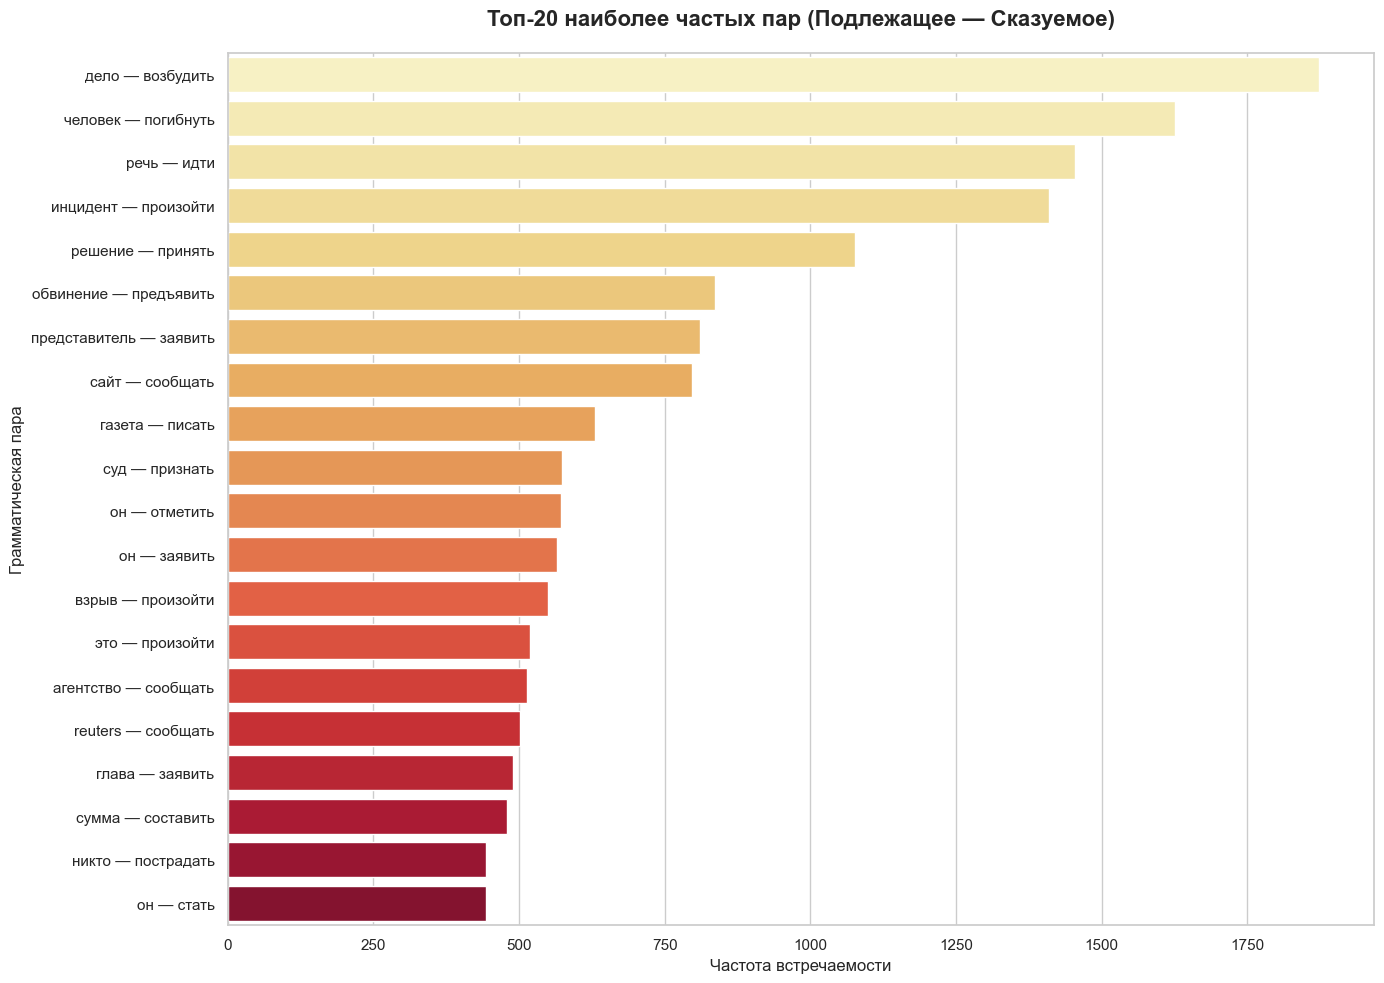

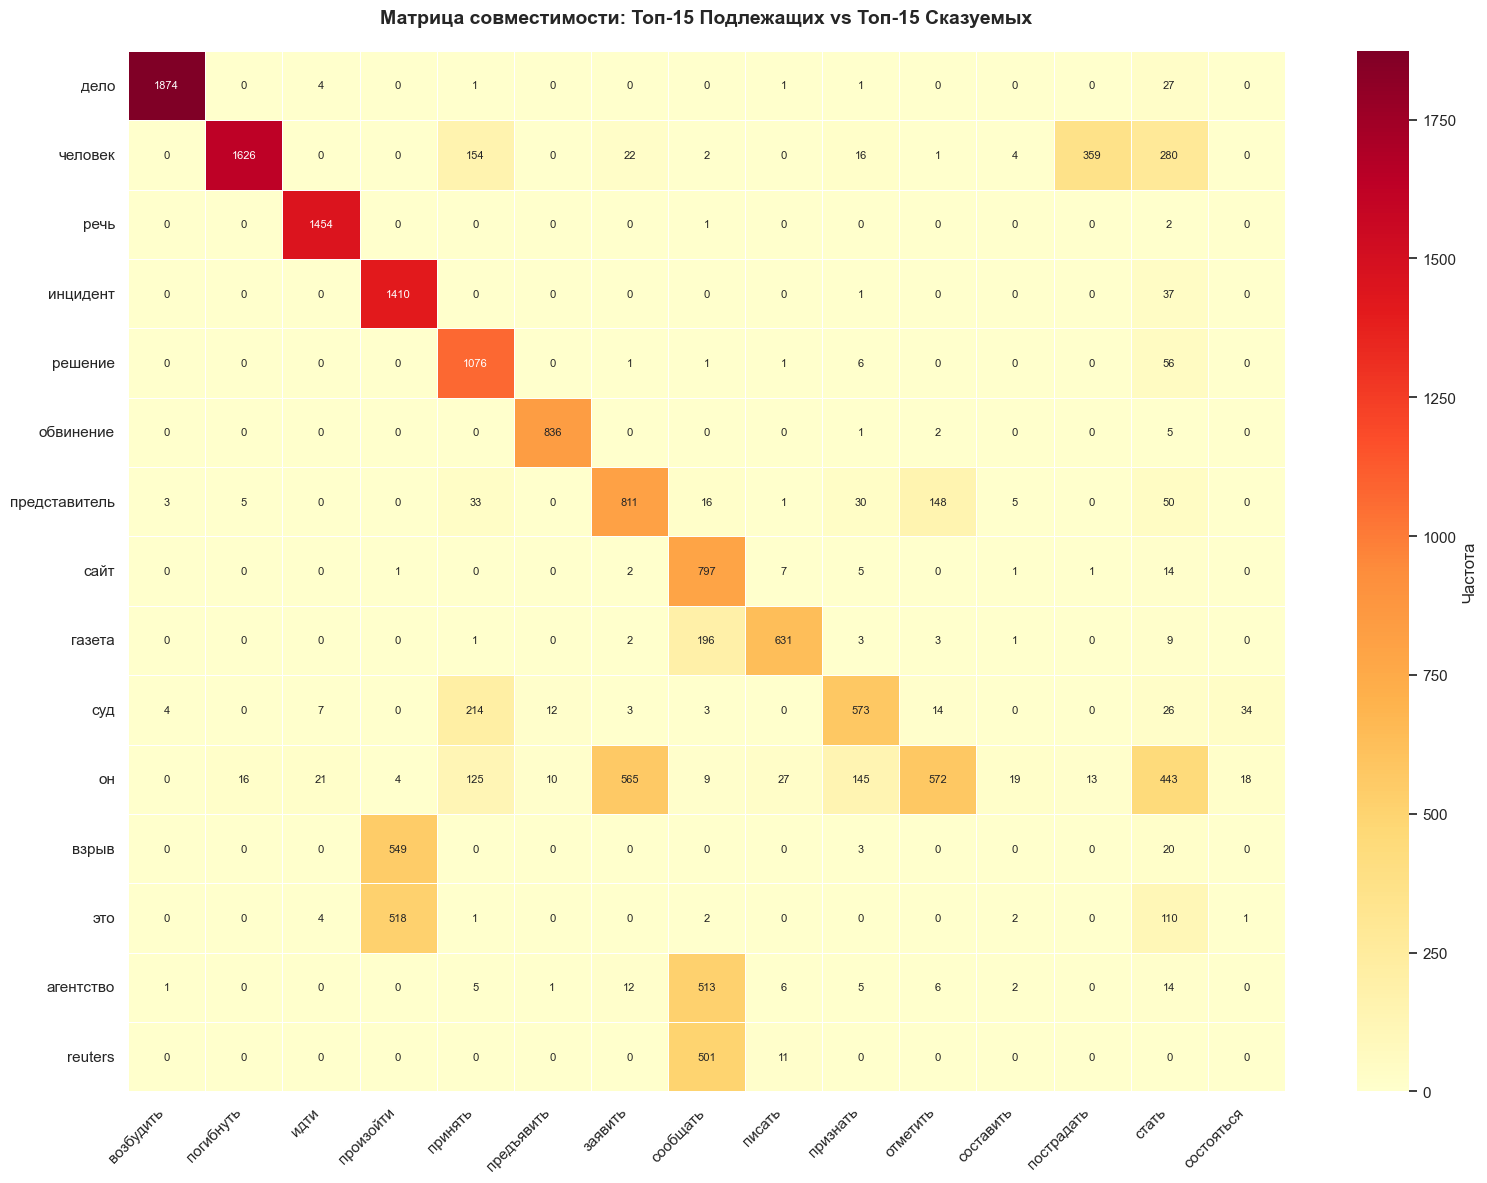

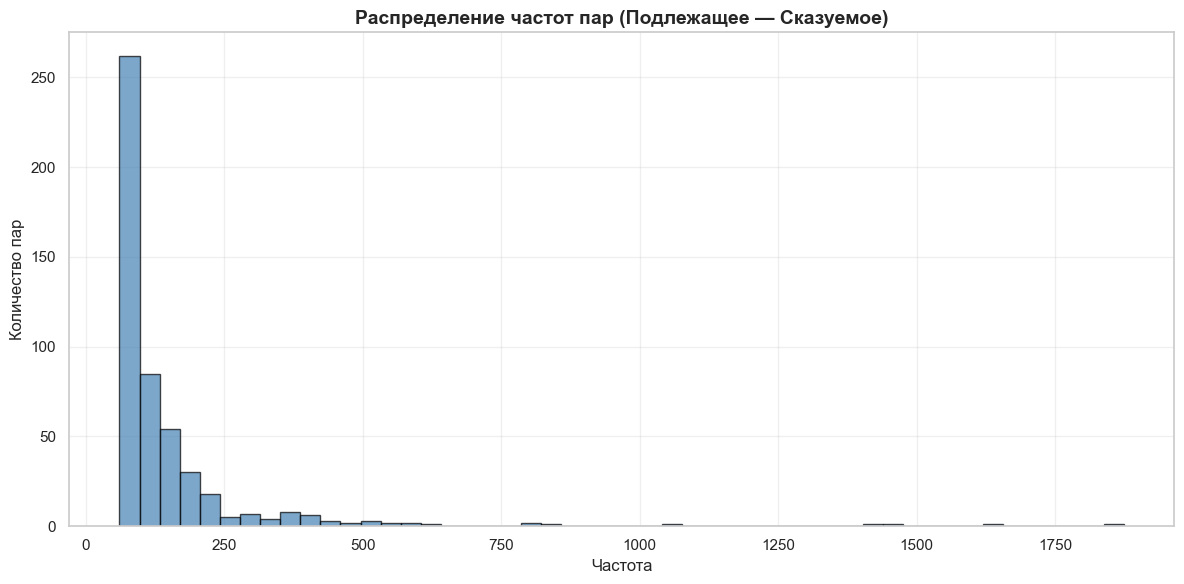

Визуализации сохранены!


In [14]:
# Построение визуализаций
print("Построение визуализаций...")
visualize_results(counter, top_n=20)
print("Визуализации сохранены!")

## Сохранение результатов

In [15]:
# Сохранение результатов в CSV
results_df = pd.DataFrame(counter.most_common(), columns=['Pair', 'Count'])
results_df['Subject'] = results_df['Pair'].apply(lambda x: x[0])
results_df['Predicate'] = results_df['Pair'].apply(lambda x: x[1])
results_df = results_df[['Subject', 'Predicate', 'Count']]
results_df.to_csv('subject_predicate_pairs.csv', index=False, encoding='utf-8-sig')
print(f"Результаты сохранены в subject_predicate_pairs.csv ({len(results_df)} пар)")

# Сохранение статистики
stats = {
    'total_articles': len(df),
    'total_pairs': len(all_pairs),
    'unique_pairs': len(counter),
    'top_pair': counter.most_common(1)[0] if counter else None
}

print("\n" + "=" * 70)
print("СТАТИСТИКА АНАЛИЗА:")
print("=" * 70)
print(f"Всего статей обработано: {stats['total_articles']}")
print(f"Всего пар найдено: {stats['total_pairs']}")
print(f"Уникальных пар: {stats['unique_pairs']}")
if stats['top_pair']:
    print(f"Самая частая пара: {stats['top_pair'][0][0]} — {stats['top_pair'][0][1]} ({stats['top_pair'][1]} вхождений)")
print("=" * 70)

Результаты сохранены в subject_predicate_pairs.csv (216562 пар)

СТАТИСТИКА АНАЛИЗА:
Всего статей обработано: 50000
Всего пар найдено: 506721
Уникальных пар: 216562
Самая частая пара: дело — возбудить (1874 вхождений)


## Выводы

1. **Техническая реализация**: Использована библиотека `spaCy` с моделью `ru_core_news_md` для синтаксического разбора русских текстов.

2. **Производительность**: Многопоточная обработка (`n_process=9`) позволила обработать ~50,000 записей за приемлемое время.

3. **Качество данных**: Предварительная очистка текстов улучшила качество токенизации и синтаксического разбора.

4. **Лингвистические закономерности**: В новостных текстах преобладают клишированные конструкции с глаголами речевого действия и описания событий.